# SINGLE CELL RNA SEQUENCING ANALYSIS - PART II

### Created by: Holly Vose
### Last Modified: 11/18/2025

This notebook is the second notebook in the analysis pipeline of single cell RNA sequencing. 

The prerequisite assumption is that there is an exported AnnData object in h5ad format to analyze. Technically this analysis can be done in the same notebook as the initial analysis, but loading the exported object takes significantly less resources than doing all analyses in the same notebook.

In [1]:
#STEP 1: Imports
#Load this first
import re
import os
import pprint
import warnings
import scanpy as sc
import anndata as ad
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

warnings.filterwarnings('ignore')
sns.set_style("ticks")

## LOADING AND SETUP

The next few steps will set up our analysis environment by:
- Loading our exported h5ad file from Part I
- Adding/redefining columns as needed
- Loading in our color/colormap constants for visualizations

In [2]:
#STEP 2: Loading the exported data
adata_filtered = sc.read_h5ad("adata_filtered_1032025.h5ad")

In [3]:
#STEP 2.5: Redefine prior categories, may not be necessary
adata_filtered.obs.loc[adata_filtered.obs["i_type"] == "infected", 'group'] = '5DPI'
adata_filtered.obs.loc[adata_filtered.obs["i_type"] == "uninfected", 'group'] = 'Mock'

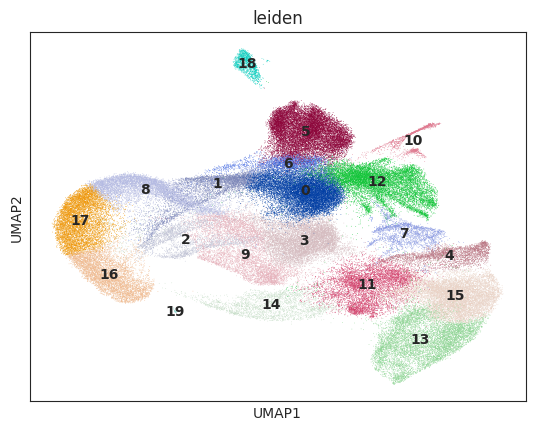

In [4]:
#STEP 3: 
sc.tl.leiden(adata_filtered, flavor="igraph", resolution=0.75, n_iterations=2)
sc.pl.umap(adata_filtered, color="leiden",legend_loc="on data")

In [8]:
#STEP 4: Load color palettes
infected_colors = {
    "5DPI": "#e88048",
    "Mock": "#582B36"
}

cluster_colors = ["#2E5283","#AC6C29","#C67FAE","#D7E8BC","#E2552D","#009499","#6D5698","#E3BD33","#98DDDF","#582B36","#A6BE47"]
i_contrast_colors = ["#E2552D","#2E5283"]
ifitm_hex = ["#BEBDBD", "#DF3848"]
dp_hex = ["#FFFFFF","#0075B8"]
aggressive_hex = ["#FFFFFF","#000000"]

ifitm_cmap = mcolors.LinearSegmentedColormap.from_list("ifitm_cmap",ifitm_hex)
aggr_cmap = mcolors.LinearSegmentedColormap.from_list("aggr_cmap",aggressive_hex)
dp_cmap = mcolors.LinearSegmentedColormap.from_list("dp_cmap",dp_hex)

# ANALYSIS METHODS
Past this point, each analysis method is optional. These are a variety of different analyses that can be performed on the data to get results back. As new analyses are requested, this notebook will be updated.

In [ ]:
#Get gene counts per cell of specified gene
genes_per_cell = np.sum(adata_filtered[:,"Mhvy"].X, axis=1)

In [5]:
#Get all genes present in the dataset
print(list(adata_filtered.var_names))

['Xkr4', 'Gm53491', 'Rp1', 'Gm37323', 'Gm46082', 'Mrpl15', 'Lypla1', 'Gm57794', 'Tcea1', 'Rgs20', 'Gm16041', 'Atp6v1h', 'Npbwr1', 'Gm46206', '4732440D04Rik', 'Rb1cc1', 'Alkal1', 'St18', 'Pcmtd1', 'Gm26901', 'Rrs1', 'Adhfe1', '2610203C22Rik', 'Vxn', 'Mybl1', 'Vcpip1', '1700034P13Rik', 'Gm39590', 'Sgk3', 'Gm6195', 'Mcmdc2', 'Snhg6', 'Tcf24', 'Ppp1r42', 'Cops5', 'Cspp1', 'Arfgef1', 'Cpa6', 'Prex2', 'Gm17644', 'Sulf1', 'Slco5a1', 'Prdm14', 'Ncoa2', 'Tram1', 'Lactb2', 'Xkr9', 'Gm5523', 'Gm39596', 'Eya1', 'Msc', 'Gm9947', 'Kcnb2', 'Gm51616', 'Terf1', 'Sbspon', 'Gm31523', '4930444P10Rik', 'Rpl7', 'Rdh10', 'Stau2', 'Gm7568', 'C130013N14Rik', 'Ube2w', 'Eloc', 'D030040B21Rik', 'Tmem70', 'Ly96', 'Jph1', 'Gdap1', 'Tfap2d', 'Tfap2b', 'Pkhd1', 'Il17a', 'Il17f', 'Mcm3', '6720483E21Rik', 'Paqr8', 'Efhc1', 'Tram2', 'Tmem14a', 'Gsta3', 'Gm7094', 'Gm4956', 'Khdc1a', 'Khdc1b', 'Kcnq5', 'Rims1', 'Gm53541', 'Ogfrl1', 'B3gat2', 'Smap1', 'Sdhaf4', 'Fam135a', 'Col9a1', 'Col19a1', 'Lmbrd1', 'Adgrb3', 'Gm20172',

In [ ]:
#Generate the top differentially expressed genes based on the specific groupby parameter
sc.tl.rank_genes_groups(adata_filtered, groupby="leiden", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    adata_filtered, groupby="leiden", standard_scale="var", n_genes=5
)

## DEFINING CLUSTER CELL TYPES
Although the leiden algorithm provides useful clustering, it may not be obvious what these clusters represent. Using the differential genes for each cluster, as well as the gene distribution within the UMAP, we can guess at which cell types correspond to which clusters. Once we know (or have a guess at) which leiden clusters correspond to which cell types, we can actually map these names to each specific cell based on the cluster they represent. Note that these are relative groupings- some clusters may not contain the cell type most representative of the whole cluster, and some cells may not actually be contained in their cluster.

There can be multiple clusters that are the same cell type depending on how fine/coarse the clustering is. If you want to change the clustering resolution, rerun `sc.tl.leiden` and change the `resolution` parameter to a more fitting option. You can't really control where the clusters occur (since it's mathematically calculated), but it can be helpful for resolving a bunch of small clusters with the same identity, or for separating groups that should clearly be separate clusters.

**How do I determine marker genes?** Look for existing datasets and literature that supports specific marker gene associated cell types. There are options to auto-detect using some sort of machine learning/AI, but I find the hand annotations are easier to find.

In [6]:
#CLUSTER DEFINITIONS
#Stem Cell: Lgr5+, Ascl2+, Muc2-, Lrig1+ (ideally)
#Tuft Cell: Dclk1+
#Colonocytes: Slc26a3+, Krt20+, Aqp8+
#TA Cells: Foxm1, Ube2c+
#Goblet Cell Progenitor: Spdef+, Atoh1+
#Goblet Cell: Reg4+, Spink4+, Tff3+, Fad3+
#Immune Signaling Cells: B2m+, Cd3g+
#EC Progenitors: B3galt5+
#Actin-Associated Genes: Actb+, Car1, Krt8

cluster2annotation = {
    "0": "Stem Cell",
    "1": "Mitochondrial-Associated Cell Stress",
    "2": "Goblet Cell", 
    "3": "Stem Cell", 
    "4": "Goblet Cell Progenitor", 
    "5": "Mitochondrial-Associated Cell Stress",
    "6": "Goblet Cell",
    "7": "Goblet Cell",
    "8": "Absorptive Colonocytes",
    "9": "Transit Amplifying Cells",
    "10": "Tuft Cells",
    "11": "Transit Amplifying Cells",
    "12": "Epithelial Cell Progenitors",
    "13": "Goblet Cell",
    "14": "Mature Enterocytes",
    "15": "Goblet Cell", 
    "16": "Absorptive Colonocytes", 
    "17": "Absorptive Colonocytes",
    "18": "Other",
    "19": "Actin-Associated Cell Stress",
}

adata_filtered.obs['cluster_cell_type'] = adata_filtered.obs["leiden"].map(cluster2annotation).astype('category')

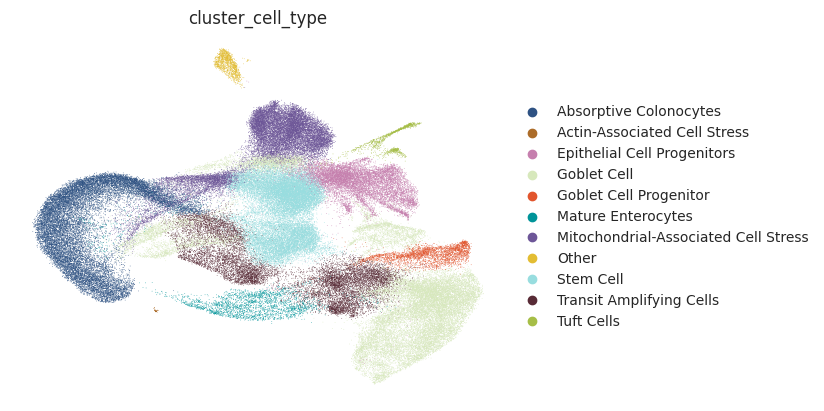

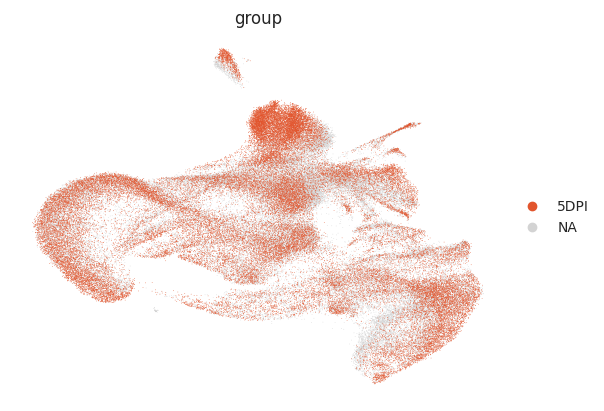

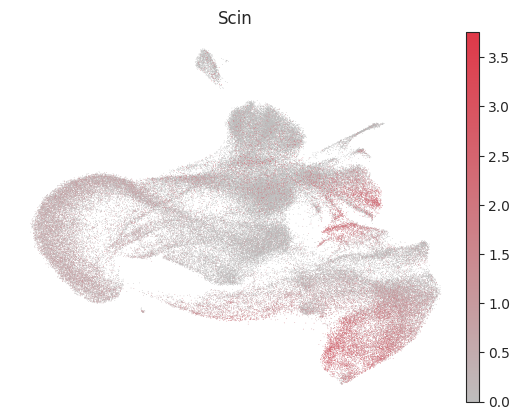

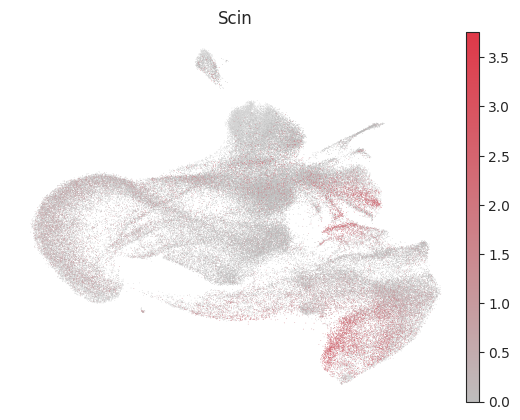

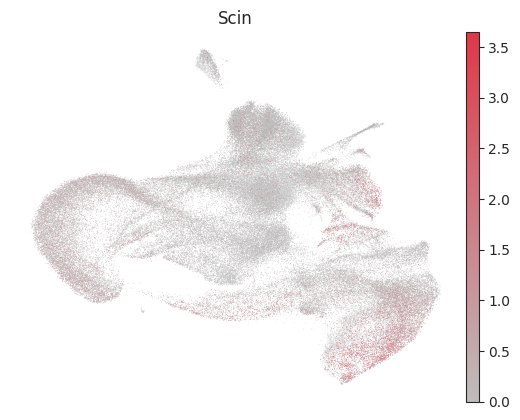

In [14]:
#PLOTTING

#basic format for a few things:
# sc.pl.umap(adata_filtered, color=[gene], size=20, mask_obs=(adata_filtered.obs.[category]==[group]), cmap=[colormap], frameon=False, save=[output filename])

#BASIC PLOTS
sc.pl.umap(adata_filtered, color=["cluster_cell_type"],palette=cluster_colors,frameon=False)
sc.pl.umap(adata_filtered, color="group",groups="5DPI",frameon=False,palette=i_contrast_colors)
sc.pl.umap(adata_filtered, color="Scin",frameon=False,cmap=ifitm_cmap,save="scin.svg")
sc.pl.umap(adata_filtered, color="Scin",frameon=False,cmap=ifitm_cmap,mask_obs=(adata_filtered.obs.group=="Mock"))
sc.pl.umap(adata_filtered, color="Scin",frameon=False,cmap=ifitm_cmap,mask_obs=(adata_filtered.obs.group=="5DPI"))
#sc.pl.umap(adata_filtered, color="group", frameon=False,palette=i_contrast_colors,title="cell sample types",save="sampleumap.svg")
# sc.pl.umap(adata_filtered, color="cluster_cell_type", frameon=False, title="cell clustering",save="i_contrast.jpg")


In [ ]:
#Ranking genes by infection then graphing by cluster cell type
sc.tl.rank_genes_groups(adata_filtered, groupby="i_type", method="wilcoxon")

sc.pl.rank_genes_groups_dotplot(
    adata_filtered, groupby="cluster_cell_type", standard_scale="var", n_genes=5, save="i_type_dotplot.svg"
)

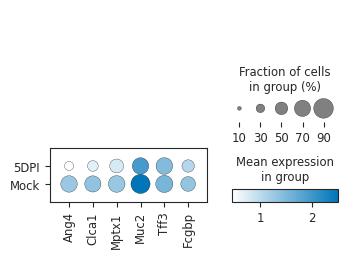

In [7]:
#generating a comparative dotplot of specific genes, compared over the groupby parameter
markers = ['Ang4','Clca1','Mptx1','Muc2','Tff3','Fcgbp']

sc.pl.dotplot(adata_filtered, markers, groupby='group',cmap=dp_cmap)


In [ ]:
#get the cell categories in list form
name_cell_types = adata_filtered.obs["cluster_cell_type"]
cell_types = name_cell_types.cat.categories.tolist()

In [ ]:
#making this a loop so it isn't stupid - per cluster basis

num_clusters = 19

for i in range(0, num_clusters):
    curr_cluster = adata_filtered[(adata_filtered.obs["leiden"] == str(i))].copy()
    sc.tl.rank_genes_groups(curr_cluster, groupby='i_type', reference='uninfected', method='wilcoxon',key_added='i_type_compare')
    current_clus = sc.get.rank_genes_groups_df(curr_cluster, group="infected",key='i_type_compare')
    title = "comp_cluster_" + str(i) + ".csv"
    current_clus.to_csv(title,index=False)

In [ ]:
#making this a loop so it isn't stupid - per cell type basis

for ctype in cell_types:
    if ctype != "Actin-Associated Cell Stress": #actin cluster doesn't have any infected cells, can't cluster by that category
        curr_cluster = adata_filtered[(adata_filtered.obs["cluster_cell_type"] == ctype)].copy()
        sc.tl.rank_genes_groups(curr_cluster, groupby='i_type', reference='uninfected', method='wilcoxon',key_added='i_type_compare')
        current_clus = sc.get.rank_genes_groups_df(curr_cluster, group="infected",key='i_type_compare')
        new_name = re.sub(" ","_",ctype)
        title = "comp_cluster_" + new_name + ".csv"
        current_clus.to_csv(title,index=False)

In [ ]:
#FINDING MHVY COUNTS IN CELL TYPE CLUSTERS
#cluster counts
all_uninfected = []
all_infected = []

for ctype in cell_types:  
    subset_in = adata_filtered[(adata_filtered.obs["cluster_cell_type"] == ctype) & (adata_filtered.obs["group"] == "5DPI")].shape[0]
    subset_un = adata_filtered[(adata_filtered.obs["cluster_cell_type"] == ctype) & (adata_filtered.obs["group"] == "Mock")].shape[0]
    total = subset_un + subset_in
    print(ctype + ": " + str(subset_un) + " + " + str(subset_in))
    #my_clusters[i] = [round(subset_un/total, 2), round(subset_in/total, 2)]
    all_uninfected.append(round(subset_un/total, 2))
    all_infected.append(round(subset_in/total, 2))

print(len(all_uninfected))
print(len(all_infected))

data = {
    "Cluster": cell_types,
    "Mock": all_uninfected,
    "5DPI": all_infected
}

df = pd.DataFrame(data)

# for keys, values in my_clusters.items():
#     print(str(keys) + ": " + str(values))

df_pivot = df.pivot_table(index='Cluster', values=['Mock','5DPI'], aggfunc='sum')

print(df_pivot)

# Set Seaborn style
sns.set_theme()
bar_colors = ["#DE3848","#009499"]

# Plot using Pandas with stacked=True
#fig, ax = plt.subplots()
plt.style.use("default")
my_plot = df_pivot.plot(kind='barh',stacked=True, figsize=(8, 6),color=bar_colors,grid=True)
my_plot.set_axisbelow(True)
plt.title('Mock vs 5DPI Cluster Proportions')
#ax.set_axisbelow(True)
#ax.yaxis.grid(color='gray', linestyle='dashed')
plt.ylabel('Cluster')
plt.xlabel('Percentage of Cluster')
plt.xticks(rotation=90)
#ax.set_facecolor('white')
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.savefig("cell_percentages.jpg", bbox_inches='tight')
plt.show()

In [10]:
#get subset of only cells with Clca1+ activity
muc = adata_filtered[:,'Muc2'].X

if isinstance(muc, (np.ndarray, list)):
    # For dense arrays or lists
    mask = muc.flatten() > 0
else:
    # For sparse matrices (e.g., csr_matrix)
    mask = (muc.toarray().flatten() > 0)

adata_subset_view = adata_filtered[mask, :]

adata_muc = adata_subset_view.copy()

In [11]:
adata_muc.write_h5ad("muc2_only_11112025.h5ad")

In [15]:
sc.tl.rank_genes_groups(adata_clca,groupby='group',reference="Mock",method="wilcoxon",key_added="clca_comp")

In [16]:
clca_clus = sc.get.rank_genes_groups_df(adata_clca, group="5DPI",key='clca_comp')
title = "clca_pos_diff_genes.csv"
clca_clus.to_csv(title,index=False)

In [ ]:
#calculating how many cells per cluster are positive for a given set of barcodes
clusters = {}
for item in valid_barcodes:
    try:
        mhv_cluster = adata_filtered[item].obs["cluster_cell_type"].iloc[0]
    except KeyError as e:
        print(str(e) + " not in valid barcodes")
    if mhv_cluster not in clusters.keys():
        clusters[mhv_cluster] = 1
    else:
        clusters[mhv_cluster] += 1

sorted_items = sorted(clusters.items(), key=lambda item: item[0])
fnl_out = dict(sorted_items)
for keys, values in fnl_out.items():
    print(str(keys) + " " + str(values))

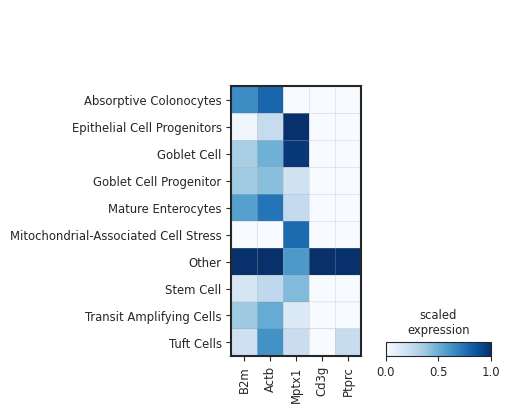

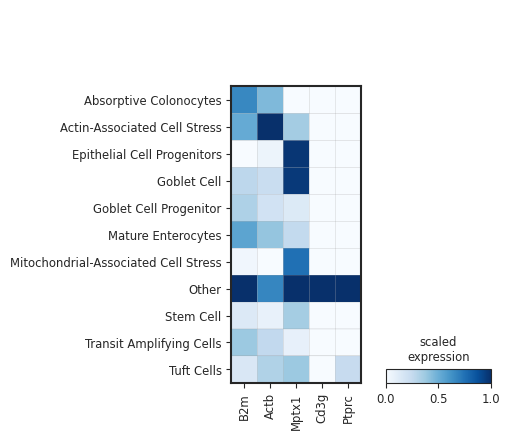

In [8]:
#generating a matrixplot based on various gene markers within a subset of the original dataset
muc_markers = ['Ang4','Clca1','Mptx1','Muc2','Tff3','Fcgbp']
stress_markers = ['B2m', 'Actb', 'Mptx1','Cd3g','Ptprc']

adata_infec = adata_filtered[(adata_filtered.obs["group"] == "5DPI")]
adata_uninfec = adata_filtered[(adata_filtered.obs["group"] == "Mock")]

sc.pl.matrixplot(
    adata_infec,
    stress_markers,
    "cluster_cell_type",
    dendrogram=False,
    cmap="Blues",
    standard_scale="var",
    colorbar_title="scaled\nexpression",
)

sc.pl.matrixplot(
    adata_uninfec,
    stress_markers,
    "cluster_cell_type",
    dendrogram=False,
    cmap="Blues",
    standard_scale="var",
    colorbar_title="scaled\nexpression",
)

In [ ]:
adata_goblet = adata_filtered[(adata_filtered.obs["cluster_cell_type"] == "Goblet Cell")]

sc.tl.rank_genes_groups(adata_goblet, groupby='group', reference='5DPI', method='wilcoxon',key_added='i_type_compare_4')
sc.get.rank_genes_groups_df(adata_goblet, group="Mock",key='i_type_compare_4')
sc.pl.rank_genes_groups_dotplot(
    adata_goblet, groupby="group", standard_scale="var", n_genes=10, key="i_type_compare_4", cmap=dp_cmap,save="Mock_goblet.svg"
)

In [ ]:
#code graveyard
all_data = []

files = ["goblet_mock_up.txt","goblet_mhvy_up.txt"]

for file in files:
    sample_name = re.search("(.+)\.txt",file).group(1)  # Adjust if your naming is different
    df = pd.read_table(file)  # Sheet name may vary
    
    # Keep only relevant columns
    df_filtered = df[['Description', 'Log(q-value)', 'Genes']]  # Adjust to your actual column names
    df_filtered['Sample'] = sample_name
    df_filtered['GeneCount'] = df_filtered['Genes'].apply(lambda x: len(str(x).split(',')))
    df_filtered['-log10(P)'] = -np.log10(df_filtered['Log(q-value)'])
    
    all_data.append(df_filtered)

# Step 2: Combine all data
combined_df = pd.concat(all_data)

# Optional: Filter for top pathways (e.g., top 10 most common)
top_terms = (
    combined_df['Description'].value_counts()
    .head(20)  # Or use frequency/mean p-value
    .index
)

plot_df = combined_df[combined_df['Description'].isin(top_terms)]

# Step 3: Plot using seaborn
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=plot_df,
    x="Sample",
    y="Description",
    size="GeneCount",
    hue="-log10(P)",
    palette="coolwarm",
    sizes=(20, 300),
    edgecolor="black",
)

plt.title("Pathway Enrichment Dot Plot Across Samples")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#adata_filtered.obs_names
in_count = 0
out_count = 0
mhvy_barcodes = {}
all_mhvy = {}
with open("/scratch/alpine/hvose@xsede.org/Krishnamurthy_07152025_GEX/MHVY_fastqs/all_mhvy_barcodes.txt") as f:
    for line in f:
        if line.strip() in adata_filtered.obs_names:
            print(line.strip() + " leiden: " + adata_filtered.obs.loc[line.strip(),'leiden'])
            mhvy_barcodes[line.strip()] = adata_filtered.obs.loc[line.strip(),'leiden']
        else:
            print(line.strip() + " not in barcodes")
        all_mhvy[line.strip()] = 0
f.close()

print(len(mhvy_barcodes.keys()))
print(len(all_mhvy.keys()))
#adata_filtered.obs.loc["AAACCAAAGCATCGGT",'leiden']